# Verify Cobots Synthetic Dataset, Checkpoint, and Inference

Loads safety-area images, folder/class metadata, ADVIS VAE-GAN checkpoint, reconstruction preview, threshold calibration, and subset inference.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from verification_helpers import *

CONFIG_NAME = "cobots.yaml"
MAX_TRAIN_SAMPLES = 512
MAX_TEST_SAMPLES = 512

/Users/rashid/miniconda3/envs/pt/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [ ]:
state = load_config_data(CONFIG_NAME)
cfg = state["cfg"]
project_root = state["project_root"]
device = state["device"]
train_dataset = state["train_dataset"]
test_dataset = state["test_dataset"]

print("config:", state["config_path"])
print("device:", device)
print("dataset:", cfg.data.name, cfg.data.category)
print("train:", state["summary"]["train"]["class_counts"])
print("test:", state["summary"]["test"]["class_counts"])
state["sample_records"](test_dataset, 5)

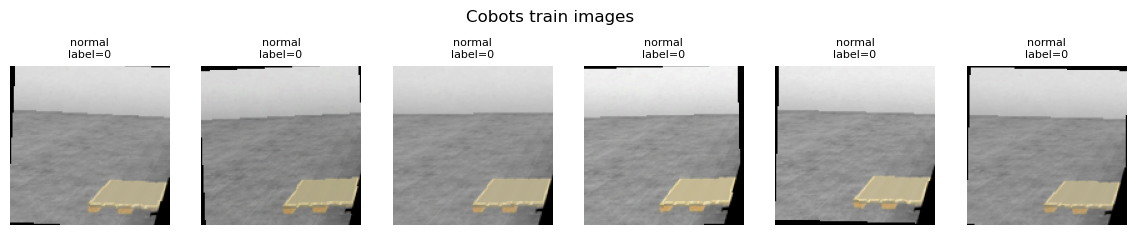

,path,file_name,folder_name,raw_label,label
0,/Users/rashid/data/DS/AD/Cobots_Synthetic/trai...,fronttop_0000_unknown.png,normal,0,0
1,/Users/rashid/data/DS/AD/Cobots_Synthetic/trai...,fronttop_0001_unknown.png,normal,0,0
2,/Users/rashid/data/DS/AD/Cobots_Synthetic/trai...,fronttop_0002_unknown.png,normal,0,0
3,/Users/rashid/data/DS/AD/Cobots_Synthetic/trai...,fronttop_0003_unknown.png,normal,0,0
4,/Users/rashid/data/DS/AD/Cobots_Synthetic/trai...,fronttop_0004_unknown.png,normal,0,0
5,/Users/rashid/data/DS/AD/Cobots_Synthetic/trai...,fronttop_0005_unknown.png,normal,0,0


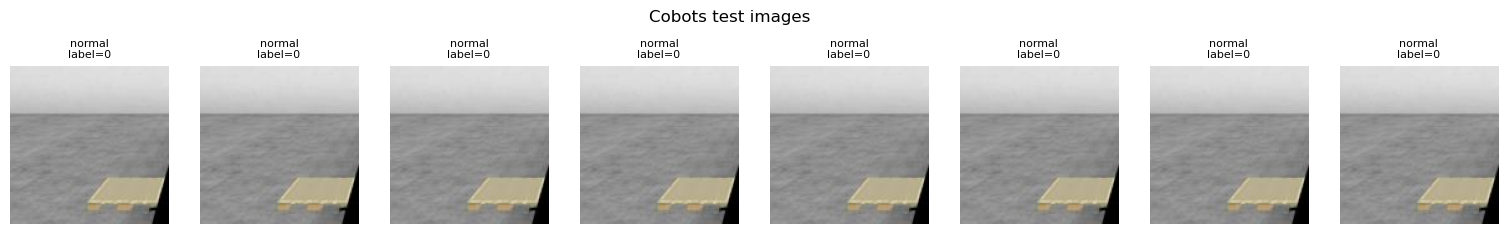

,path,file_name,folder_name,raw_label,label
0,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540057414289200_0000_10000010000000000.jpg,normal,0,0
1,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540057618711700_0001_10000010000000000.jpg,normal,0,0
2,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540057814921500_0002_10000010000000000.jpg,normal,0,0
3,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540058016968900_0003_10000010000000000.jpg,normal,0,0
4,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540058225298700_0004_10000010000000000.jpg,normal,0,0
5,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540058398410400_0005_10000010000000000.jpg,normal,0,0
6,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540058609105900_0006_10000010000000000.jpg,normal,0,0
7,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540058800234600_0007_10000010000000000.jpg,normal,0,0


In [ ]:
display(show_samples(train_dataset, "Cobots train images", max_images=6))
display(show_samples(test_dataset, "Cobots test images", max_images=8))

In [ ]:
checkpoint_path, encoder, decoder, discriminator = load_vaegan_model(cfg, device)
print("checkpoint:", checkpoint_path)
print("exists:", checkpoint_path.exists())
show_reconstructions(encoder, decoder, state["test_loader"], device, max_images=6)

checkpoint: /Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/checkpoints/AD_Cobots_Synthetic/model_PLeft_64.pt
exists: True


/Users/rashid/Nextcloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/notebooks/verification_helpers.py:169: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
training_history, training_artifacts = show_training_curves(project_root, cfg, checkpoint_path)
training_artifacts


In [ ]:
metrics, results_df, threshold_model = run_subset_inference(
    cfg, encoder, decoder, discriminator,
    train_dataset, test_dataset,
    max_train_samples=MAX_TRAIN_SAMPLES,
    max_test_samples=MAX_TEST_SAMPLES,
)
display(metrics)
display(results_df.head())
display(results_df.groupby("folder_name")[["binary_label", "prediction"]].agg(["count", "mean"]))

Scoring (l2): 100%|██████████| 32/32 [00:00<00:00, 45.06it/s]


{'auroc': 1.0,
 'auprc': 1.0,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'tp': 0,
 'tn': 346,
 'fn': 166,
 'fp': 0}

,path,file_name,folder_name,class_idx,class_name,binary_label,prediction,score
0,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540057414289200_0000_10000010000000000.jpg,normal,0,normal,0,0,5.326517
1,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540057618711700_0001_10000010000000000.jpg,normal,0,normal,0,0,5.326517
2,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540057814921500_0002_10000010000000000.jpg,normal,0,normal,0,0,5.326517
3,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540058016968900_0003_10000010000000000.jpg,normal,0,normal,0,0,5.326517
4,/Users/rashid/data/DS/AD/Cobots_Synthetic/test...,1751540058225298700_0004_10000010000000000.jpg,normal,0,normal,0,0,5.326517


binary_label      prediction     
                         count mean      count mean
folder_name                                        
normal                     346  0.0        346  0.0
unexpected_person          166  1.0        166  0.0

In [ ]:
output_dir = save_notebook_outputs(project_root, cfg.data.name, cfg.data.category, metrics, results_df, state["summary"])
print(output_dir)